In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

Initialize parameters:
- k_on = binding rate (of ligand to receptor)
- k_off = unbining rate (ligand popping off receptor)
- c = concentration of ligand (how much is floating around in the extracellular space?)
- t_max = maximum amount of time to run the simulation
- state_init = start at the unbound state
- key = reproducible random number generator for the time step jumps

In [2]:
# ------------------------------
# Parameters
# ------------------------------
k_on = 1.0           # binding rate constant (per M/s)
k_off = 0.1          # unbinding rate constant (per s)
c = 1.0              # ligand concentration (M)
t_max = 100.0        # total simulation time
state_init = 0       # initial receptor state: 0 = unbound, 1 = bound
key = jax.random.PRNGKey(42)  # reproducible RNG

In [3]:

# ------------------------------
# Simulation Setup
# ------------------------------
def kmc_step(state, t, key):
    """
    Perform one KMC step for the 2-state system.
    """
    k_bind = k_on * c      # rate for 0 → 1
    k_unbind = k_off       # rate for 1 → 0

    if state == 0:
        rate = k_bind
        next_state = 1
    else:
        rate = k_unbind
        next_state = 0

    # Draw a random number for time step
    key, subkey = jax.random.split(key)
    r = jax.random.uniform(subkey)

    # the delta_t depends on the bind/unbind rate 
    # small rate here = we wait a long time before unbinding. Large rate - next transition comes quickly
    delta_t = -jnp.log(r) / rate

    return next_state, t + delta_t, delta_t, key

# ------------------------------
# Run Simulation
# ------------------------------
def run_kmc(state_init, t_max, key):
    state = state_init
    t = 0.0
    times = [0.0]
    states = [state]

    while t < t_max:
        state, t, dt, key = kmc_step(state, t, key)
        times.append(t)
        states.append(state)

    return jnp.array(times), jnp.array(states)

# Run it
times, states = run_kmc(state_init, t_max, key)

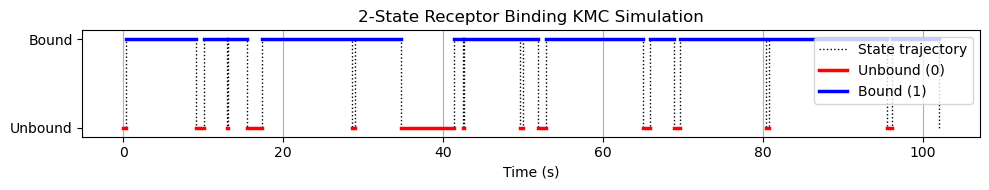

In [4]:

# Convert states into Y-values for plotting
y_unbound = jnp.where(states == 0, 0, jnp.nan)
y_bound = jnp.where(states == 1, 1, jnp.nan)

plt.figure(figsize=(10, 2))

# Thin dotted line connecting all transitions
plt.step(times, states, where='post', color='black', linestyle=':', linewidth=1.0, label='State trajectory')

plt.step(times, y_unbound, where='post', color='red', label='Unbound (0)', linewidth=2.5)
plt.step(times, y_bound, where='post', color='blue', label='Bound (1)', linewidth=2.5)

plt.ylim(-0.1, 1.1)
plt.yticks([0, 1], labels=['Unbound', 'Bound'])
plt.xlabel('Time (s)')
plt.title('2-State Receptor Binding KMC Simulation')
plt.grid(True, axis='x')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()